## Step 2) Participation in Ancillary Service Markets

### Task 2.1) In-sample Decision Making: Offering Strategy Under the P90 Requirement
Using the 100 in-sample profiles, determine the optimal FCR-D UP reserve bid (in kW) satisfying Energinet’s P90 requirement. Solve the problem using both ALSO-X and CVaR.

### Initialization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

In [2]:
# --------------------------------------------------
# Parameters
# --------------------------------------------------
LOAD_MIN = 220.0     # kW #For part 2.1
EPSILON = 0.10       # P90 => max 10% violation #For part 2.1
P90_TARGET = 0.90 #For part 2.2

# Reliability levels to test: 80% ... 100% #For part 2.3
reliability_levels = np.arange(0.80, 1.001, 0.02)

### Load data Task 2.1

In [3]:
# --------------------------------------------------
# Load the 100 in-sample profiles
# Assumes each row = one profile, each column = one minute
# If your CSV has an index column, set index_col=0
# --------------------------------------------------
in_sample = pd.read_csv("in_sample_profiles.csv")

# Optional cleanup in case there is a profile_id or probability column
drop_cols = [c for c in ["profile_id", "probability"] if c in in_sample.columns]
if drop_cols:
    in_sample = in_sample.drop(columns=drop_cols)

# Convert to numpy array
profiles = in_sample.to_numpy(dtype=float)

print("In-sample profile matrix shape:", profiles.shape)

In-sample profile matrix shape: (100, 60)


### FCR-D Task 2.1

In [4]:
# --------------------------------------------------
# FCR-D UP reserve available from flexible load
# reserve = load - minimum feasible load
# --------------------------------------------------
reserve_samples = profiles - LOAD_MIN   # shape: (100, 60)

# Flatten to all minute-scenario samples
x = reserve_samples.ravel()

# --------------------------------------------------
# ALSO-X
# In this scalar bid setting, ALSO-X reduces to the empirical
# epsilon-quantile: largest bid with at most 10% violations
# --------------------------------------------------
def solve_alsox_bid(samples, epsilon=0.10):
    samples = np.sort(np.asarray(samples))
    n = len(samples)
    q = int(np.floor(epsilon * n))
    return float(samples[q])

### CVAR

In [5]:
# --------------------------------------------------
# CVaR formulation
#
# maximize c
# s.t. CVaR_epsilon(c - reserve) <= 0
#
# LP variables: [c, eta, s_1, ..., s_n]
# --------------------------------------------------
def solve_cvar_bid(samples, epsilon=0.10):
    samples = np.asarray(samples)
    n = len(samples)

    n_vars = 2 + n
    idx_c = 0
    idx_eta = 1
    idx_s = 2

    # linprog minimizes, so minimize -c
    obj = np.zeros(n_vars)
    obj[idx_c] = -1.0

    A_ub = []
    b_ub = []

    # c - sample_i - eta <= s_i
    # <=> c - eta - s_i <= sample_i
    for i, xi in enumerate(samples):
        row = np.zeros(n_vars)
        row[idx_c] = 1.0
        row[idx_eta] = -1.0
        row[idx_s + i] = -1.0
        A_ub.append(row)
        b_ub.append(xi)

    # eta + (1 / (epsilon*n)) * sum(s_i) <= 0
    row = np.zeros(n_vars)
    row[idx_eta] = 1.0
    row[idx_s:] = 1.0 / (epsilon * n)
    A_ub.append(row)
    b_ub.append(0.0)

    bounds = [(0, None), (None, None)] + [(0, None)] * n

    res = linprog(
        c=obj,
        A_ub=np.array(A_ub),
        b_ub=np.array(b_ub),
        bounds=bounds,
        method="highs"
    )

    if not res.success:
        raise RuntimeError(f"CVaR optimization failed: {res.message}")

    return float(res.x[idx_c])


### Solve task 2.1

In [6]:
# --------------------------------------------------
# Solve Task 2.1
# --------------------------------------------------
alsox_bid = solve_alsox_bid(x, EPSILON)
cvar_bid = solve_cvar_bid(x, EPSILON)

alsox_violation = np.mean(x < alsox_bid)
cvar_violation = np.mean(x < cvar_bid)

print("\nTask 2.1 results")
print(f"ALSO-X bid: {alsox_bid:.2f} kW")
print(f"CVaR bid:   {cvar_bid:.2f} kW")

print("\nIn-sample empirical violation rates")
print(f"ALSO-X: {100*alsox_violation:.2f}%")
print(f"CVaR:   {100*cvar_violation:.2f}%")


Task 2.1 results
ALSO-X bid: 45.03 kW
CVaR bid:   24.26 kW

In-sample empirical violation rates
ALSO-X: 10.00%
CVaR:   4.83%


### Task 2.2) Verification of the P90 Requirement Using Out-of-Sample Analysis
Using the 200 out-of-sample profiles, verify whether the P90 requirement is met for each solution method. No optimization is needed—compare the chosen reserve bid with the minute-level consumption profiles to evaluate possible shortfalls

### Load data Task 2.2

In [27]:
# --------------------------------------------------
# Load out-of-sample profiles
# --------------------------------------------------
out_sample = pd.read_csv("out_of_sample_profiles.csv")

# Optional cleanup if extra columns exist
drop_cols = [c for c in ["profile_id", "probability"] if c in out_sample.columns]
if drop_cols:
    out_sample = out_sample.drop(columns=drop_cols)

out_profiles = out_sample.to_numpy(dtype=float)

print("Out-of-sample profile matrix shape:", out_profiles.shape)

Out-of-sample profile matrix shape: (200, 60)


### FCR-D Task 2.2

In [28]:
# --------------------------------------------------
# Available FCR-D UP reserve
# reserve = load - minimum feasible load
# --------------------------------------------------
out_reserve = out_profiles - LOAD_MIN   # shape: (200, 60)

# Flatten all minute-scenario observations
x_out = out_reserve.ravel()

### Evaluate bid Task 2.2

In [29]:
# --------------------------------------------------
# Function to evaluate a fixed bid
# --------------------------------------------------
def evaluate_bid(bid, reserve_samples):
    reserve_samples = np.asarray(reserve_samples).ravel()

    shortfall_mask = reserve_samples < bid
    reliability = 1.0 - np.mean(shortfall_mask)   # fraction with no shortfall
    shortfall_rate = np.mean(shortfall_mask)

    if np.any(shortfall_mask):
        shortfall_amounts = bid - reserve_samples[shortfall_mask]
        avg_shortfall = np.mean(shortfall_amounts)
        max_shortfall = np.max(shortfall_amounts)
    else:
        avg_shortfall = 0.0
        max_shortfall = 0.0

    return {
        "bid_kW": bid,
        "reliability": reliability,
        "shortfall_rate": shortfall_rate,
        "meets_P90": reliability >= P90_TARGET,
        "num_shortfalls": int(np.sum(shortfall_mask)),
        "num_total": len(reserve_samples),
        "avg_shortfall_kW": avg_shortfall,
        "max_shortfall_kW": max_shortfall,
    }

# --------------------------------------------------
# Evaluate BOTH bids from Task 2.1
# Assumes alsox_bid and cvar_bid were computed in the previous cell
# --------------------------------------------------
alsox_result = evaluate_bid(alsox_bid, x_out)
cvar_result  = evaluate_bid(cvar_bid, x_out)

### Print results and summary between 2.1 and 2.2

In [30]:
# --------------------------------------------------
# Print results
# --------------------------------------------------
def print_result(name, result):
    print(f"\n{name}")
    print(f"Bid: {result['bid_kW']:.2f} kW")
    print(f"Reliability: {100*result['reliability']:.2f}%")
    print(f"Shortfall rate: {100*result['shortfall_rate']:.2f}%")
    print(f"Shortfalls: {result['num_shortfalls']} / {result['num_total']}")
    print(f"Average shortfall magnitude: {result['avg_shortfall_kW']:.2f} kW")
    print(f"Maximum shortfall magnitude: {result['max_shortfall_kW']:.2f} kW")
    print(f"Meets P90 requirement: {'Yes' if result['meets_P90'] else 'No'}")

print("=== Task 2.2: Out-of-sample verification of P90 ===")
print_result("ALSO-X solution", alsox_result)
print_result("CVaR solution", cvar_result)

# --------------------------------------------------
# Optional summary table
# --------------------------------------------------
summary = pd.DataFrame([
    {
        "Method": "ALSO-X",
        "Bid (kW)": alsox_result["bid_kW"],
        "Reliability (%)": 100 * alsox_result["reliability"],
        "Shortfall rate (%)": 100 * alsox_result["shortfall_rate"],
        "Avg shortfall (kW)": alsox_result["avg_shortfall_kW"],
        "Max shortfall (kW)": alsox_result["max_shortfall_kW"],
        "Meets P90": alsox_result["meets_P90"],
    },
    {
        "Method": "CVaR",
        "Bid (kW)": cvar_result["bid_kW"],
        "Reliability (%)": 100 * cvar_result["reliability"],
        "Shortfall rate (%)": 100 * cvar_result["shortfall_rate"],
        "Avg shortfall (kW)": cvar_result["avg_shortfall_kW"],
        "Max shortfall (kW)": cvar_result["max_shortfall_kW"],
        "Meets P90": cvar_result["meets_P90"],
    },
])

print("\nSummary table:")
display(summary)

=== Task 2.2: Out-of-sample verification of P90 ===

ALSO-X solution
Bid: 45.03 kW
Reliability: 91.63%
Shortfall rate: 8.37%
Shortfalls: 1004 / 12000
Average shortfall magnitude: 19.81 kW
Maximum shortfall magnitude: 45.00 kW
Meets P90 requirement: Yes

CVaR solution
Bid: 24.26 kW
Reliability: 96.25%
Shortfall rate: 3.75%
Shortfalls: 450 / 12000
Average shortfall magnitude: 11.13 kW
Maximum shortfall magnitude: 24.23 kW
Meets P90 requirement: Yes

Summary table:


,Method,Bid (kW),Reliability (%),Shortfall rate (%),Avg shortfall (kW),Max shortfall (kW),Meets P90
0,ALSO-X,45.029324,91.633333,8.366667,19.806048,45.00284,True
1,CVaR,24.257454,96.250000,3.750000,11.129581,24.23097,True


### Task 2.3) Energinet Perspective
Analyze how modifying the P90 requirement (e.g., threshold between 80% and 100%) affects the
optimal reserve bid (in-sample) and the expected reserve shortfall (out-of-sample) when using
ALSO-X. Discuss whether a trade-off emerges between higher reliability and reduced reserve
provision.

### Load data Task 2.3

In [31]:
# --------------------------------------------------
# Load in-sample and out-of-sample profiles
# --------------------------------------------------
in_sample = pd.read_csv("in_sample_profiles.csv")
out_sample = pd.read_csv("out_of_sample_profiles.csv")

# Drop optional non-minute columns
drop_cols_in = [c for c in ["profile_id", "probability"] if c in in_sample.columns]
drop_cols_out = [c for c in ["profile_id", "probability"] if c in out_sample.columns]

if drop_cols_in:
    in_sample = in_sample.drop(columns=drop_cols_in)
if drop_cols_out:
    out_sample = out_sample.drop(columns=drop_cols_out)

in_profiles = in_sample.to_numpy(dtype=float)
out_profiles = out_sample.to_numpy(dtype=float)

### FCR-D Task 2.3

In [32]:
# Available FCR-D UP reserve
in_reserve = (in_profiles - LOAD_MIN).ravel()
out_reserve = (out_profiles - LOAD_MIN).ravel()

### ALSO-X

In [33]:
# --------------------------------------------------
# ALSO-X bid for a chosen reliability level
# reliability = 1 - epsilon
# bid = empirical epsilon-quantile
# --------------------------------------------------
def solve_alsox_bid(samples, reliability):
    epsilon = 1.0 - reliability
    samples = np.sort(np.asarray(samples))
    n = len(samples)

    # handle 100% reliability separately
    if epsilon <= 0:
        return float(np.min(samples))

    q = int(np.floor(epsilon * n))
    q = min(max(q, 0), n - 1)
    return float(samples[q])

### Evaluate bid Task 2.3

In [34]:
# --------------------------------------------------
# Evaluate bid out-of-sample
# --------------------------------------------------
def evaluate_bid(bid, reserve_samples):
    reserve_samples = np.asarray(reserve_samples)
    shortfall_mask = reserve_samples < bid

    reliability = 1.0 - np.mean(shortfall_mask)
    shortfall_rate = np.mean(shortfall_mask)
    shortfall_amount = np.maximum(bid - reserve_samples, 0.0)
    expected_shortfall = np.mean(shortfall_amount)  # expected shortfall over all observations

    if np.any(shortfall_mask):
        conditional_shortfall = np.mean(shortfall_amount[shortfall_mask])
        max_shortfall = np.max(shortfall_amount[shortfall_mask])
    else:
        conditional_shortfall = 0.0
        max_shortfall = 0.0

    return {
        "reliability": reliability,
        "shortfall_rate": shortfall_rate,
        "expected_shortfall": expected_shortfall,
        "conditional_shortfall": conditional_shortfall,
        "max_shortfall": max_shortfall,
        "num_shortfalls": int(np.sum(shortfall_mask)),
        "num_total": len(reserve_samples),
    }

### Print results and summary Task 2.3

In [35]:
# --------------------------------------------------
# Sweep reliability thresholds
# --------------------------------------------------
results = []

for rel in reliability_levels:
    bid = solve_alsox_bid(in_reserve, rel)
    eval_out = evaluate_bid(bid, out_reserve)

    results.append({
        "P-threshold (%)": 100 * rel,
        "In-sample ALSO-X bid (kW)": bid,
        "Out-of-sample reliability (%)": 100 * eval_out["reliability"],
        "Out-of-sample shortfall rate (%)": 100 * eval_out["shortfall_rate"],
        "Expected shortfall (kW)": eval_out["expected_shortfall"],
        "Conditional shortfall (kW)": eval_out["conditional_shortfall"],
        "Max shortfall (kW)": eval_out["max_shortfall"],
    })

results_df = pd.DataFrame(results)

print("=== Task 2.3: Energinet perspective using ALSO-X ===")
display(results_df.round(3))

=== Task 2.3: Energinet perspective using ALSO-X ===


,P-threshold (%),In-sample ALSO-X bid (kW),Out-of-sample reliability (%),Out-of-sample shortfall rate (%),Expected shortfall (kW),Conditional shortfall (kW),Max shortfall (kW)
0,80.0,82.480,80.567,19.433,6.750,34.734,82.453
1,82.0,75.835,82.800,17.200,5.534,32.173,75.808
2,84.0,68.911,84.883,15.117,4.418,29.226,68.884
3,86.0,60.744,87.375,12.625,3.284,26.016,60.717
4,88.0,52.480,89.767,10.233,2.346,22.925,52.454
5,90.0,44.927,91.658,8.342,1.649,19.763,44.901
6,92.0,37.220,93.500,6.500,1.080,16.621,37.194
7,94.0,29.590,95.175,4.825,0.646,13.387,29.563
8,96.0,19.694,97.125,2.875,0.267,9.296,19.667
9,98.0,10.724,98.592,1.408,0.074,5.221,10.697


### Plot Task 2.3

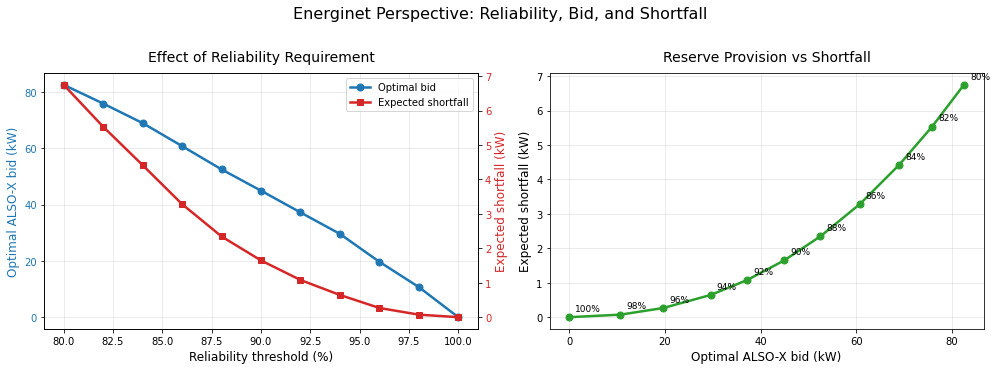

In [36]:
p_vals = results_df["P-threshold (%)"].to_numpy(dtype=float)
bid_vals = results_df["In-sample ALSO-X bid (kW)"].to_numpy(dtype=float)
exp_short_vals = results_df["Expected shortfall (kW)"].to_numpy(dtype=float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --------------------------------------------------
# Left: Reliability threshold -> bid + expected shortfall
# --------------------------------------------------
line1 = ax1.plot(
    p_vals, bid_vals,
    marker="o", linewidth=2.5, markersize=7,
    color="tab:blue",
    label="Optimal bid"
)
ax1.set_xlabel("Reliability threshold (%)", fontsize=12)
ax1.set_ylabel("Optimal ALSO-X bid (kW)", fontsize=12, color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax1b = ax1.twinx()
line2 = ax1b.plot(
    p_vals, exp_short_vals,
    marker="s", linewidth=2.5, markersize=6,
    color="tab:red",
    label="Expected shortfall"
)
ax1b.set_ylabel("Expected shortfall (kW)", fontsize=12, color="tab:red")
ax1b.tick_params(axis="y", labelcolor="tab:red")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best", frameon=True)
ax1.set_title("Effect of Reliability Requirement", fontsize=14, pad=12)

# --------------------------------------------------
# Right: Direct trade-off
# --------------------------------------------------
ax2.plot(
    bid_vals, exp_short_vals,
    marker="o", linewidth=2.5, markersize=7,
    color="tab:green"
)
ax2.set_xlabel("Optimal ALSO-X bid (kW)", fontsize=12)
ax2.set_ylabel("Expected shortfall (kW)", fontsize=12)
ax2.set_title("Reserve Provision vs Shortfall", fontsize=14, pad=12)
ax2.grid(True, alpha=0.3)

for x, y, p in zip(bid_vals, exp_short_vals, p_vals):
    ax2.annotate(f"{p:.0f}%", (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)

plt.suptitle("Energinet Perspective: Reliability, Bid, and Shortfall", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()